In [50]:
import pandas as pd

df = pd.read_csv("/Users/miriambenali/Desktop/Project-Simplon/HR-pulse-ai-platform/data/cleaned_data/cleaned_data.csv")
df.head()

,Rating,Company Name,Industry,Sector,mean_salary,seniority,job_role,skills,log_revenue,company_age,size_category
0,3.1,healthfirst,insurance carriers,insurance,154000.0,senior,data scientist,Azure Machine Learning,19.519293,33.0,medium
1,4.2,mantech,research development,business services,154000.0,mid,data scientist,SQL Machine Learning,21.128731,58.0,large
2,3.8,analysis group,consulting,business services,154000.0,mid,data scientist,Python Machine Learning,19.519293,45.0,medium
3,3.5,inficon,electrical electronic manufacturing,manufacturing,154000.0,mid,data scientist,Python SQL Machine Learning,19.519293,26.0,medium
4,2.9,affinity solutions,advertising marketing,business services,154000.0,mid,data scientist,Python SQL Machine Learning,19.519293,28.0,small


In [51]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["mean_salary"])
y = df["mean_salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size= 0.2,
    random_state= 42
)


In [52]:
# Colonnes numériques
num_features = ['company_age', "Rating"]

# Colonnes catégorielles (faible cardinalité)
cat_features = ['Industry', 'Sector', 'size_category',"log_revenue", "seniority", "job_role", "skills"]

# Colonnes texte (haute cardinalité / texte libre) → à encoder différemment
text_features = ['Company Name']

In [53]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Numérique : imputer + scaler
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Catégoriel : imputer + OHE
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [54]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer 

'''# Texte : TF-IDF (pour Job Title surtout, Job Description optionnel) 
title_transformer = TfidfVectorizer(max_features=50, ngram_range=(1,2)) 
desc_transformer = TfidfVectorizer(max_features=100, stop_words='english') '''
preprocessor = ColumnTransformer(transformers=[ 
    ('num', num_transformer, num_features), 
    ('cat', cat_transformer, cat_features), 
     ],
    remainder='drop') # drop Company Name (trop de cardinalité)'''

In [55]:
from sklearn.ensemble import RandomForestRegressor

model = Pipeline([ 
    ('preprocessor', preprocessor), 
    ('regressor', RandomForestRegressor(
        n_estimators=100,

        random_state=42)) ]) 
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [56]:
y_pred = model.predict(X_test)

In [57]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test)
print("MAE :", mean_absolute_error(y_test, y_pred))
print("R²  :", r2_score(y_test, y_pred))

MAE : 26099.0313808438
R²  : -0.09354119071719413


In [58]:
import joblib

joblib.dump(model, "/Users/miriambenali/Desktop/Project-Simplon/HR-pulse-ai-platform/model/hr_ai_platform.pkl")

['/Users/miriambenali/Desktop/Project-Simplon/HR-pulse-ai-platform/model/hr_ai_platform.pkl']

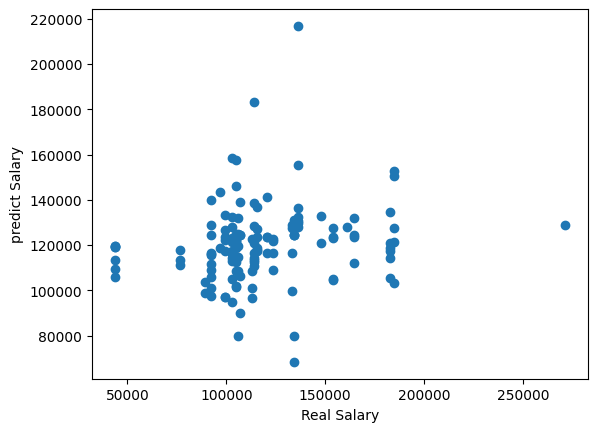

In [59]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Real Salary")
plt.ylabel("predict Salary")
plt.show()

In [60]:
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Train R²:", train_score)
print("Test R²:", test_score)

Train R²: 0.6038228463361641
Test R²: -0.09354119071719413


In [61]:
df.columns

Index(['Rating', 'Company Name', 'Industry', 'Sector', 'mean_salary',
       'seniority', 'job_role', 'skills', 'log_revenue', 'company_age',
       'size_category'],
      dtype='str')